# Feature Engineering and Modeling

## Goal
Build customer-level features from order history, train three classification
models of increasing complexity, and compare their performance honestly.

---

## Design Decision: Recency and Data Leakage
Recency (days since last purchase) is included as a feature.
Churn is defined as no purchase in the last 90 days from the snapshot date.
This means recency directly encodes the churn label — a known limitation.

This is documented in the Limitations section. In a production environment,
a temporal train/test split on a dataset with sufficient repeat purchase
history would resolve this. The Olist dataset's repeat purchase rate of
less than 3% makes that approach impractical — 99%+ of customers never
returned regardless of time window, leaving no meaningful active class
to learn from. The snapshot approach is the appropriate choice for this dataset.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries ready.")

Libraries ready.


In [2]:
orders_enriched = pd.read_csv('../data/processed/orders_enriched.csv',
                               parse_dates=['order_purchase_timestamp'])
products        = pd.read_csv('../data/raw/olist_products_dataset.csv')
items           = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
reviews         = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
payments        = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')

print(f"orders_enriched: {orders_enriched.shape}")
print(f"\nDate range:")
print(f"  Earliest: {orders_enriched['order_purchase_timestamp'].min().date()}")
print(f"  Latest:   {orders_enriched['order_purchase_timestamp'].max().date()}")

orders_enriched: (96478, 11)

Date range:
  Earliest: 2016-09-15
  Latest:   2018-08-29


---
## Sprint 5 — Feature Engineering

### Framework: RFM + Behavioral Features

Every feature is computed from the full order history per customer.
The snapshot date is the latest date in the dataset minus one day —
this is our model's definition of "now."

Features built:
- Recency: days since last purchase
- Frequency: total number of orders
- Monetary: total spend
- Avg order value: monetary divided by frequency
- Customer lifespan: days between first and last purchase
- Unique categories: how many product categories purchased from
- Total items: total individual items purchased
- Avg review score: satisfaction signal
- Review count: platform engagement signal
- Avg installments: financial commitment signal
- Used credit card: binary payment behavior flag

In [3]:
snapshot_date = orders_enriched['order_purchase_timestamp'].max() - pd.Timedelta(days=1)

rfm = orders_enriched.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency = ('order_id', 'count'),
    monetary  = ('order_value', 'sum')
).reset_index()

rfm['recency'] = rfm['recency'].clip(lower=0)

print(f"Snapshot date:   {snapshot_date.date()}")
print(f"RFM table shape: {rfm.shape}")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

Snapshot date:   2018-08-28
RFM table shape: (93358, 4)
        recency  frequency  monetary
count  93358.00   93358.00  93358.00
mean     235.94       1.03    165.20
std      152.59       0.21    226.31
min        0.00       1.00      0.00
25%      112.00       1.00     63.05
50%      217.00       1.00    107.78
75%      344.00       1.00    182.56
max      712.00      15.00  13664.08


In [4]:
rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']

lifespan = orders_enriched.groupby('customer_unique_id').agg(
    first_purchase = ('order_purchase_timestamp', 'min'),
    last_purchase  = ('order_purchase_timestamp', 'max')
).reset_index()

lifespan['customer_lifespan_days'] = (
    lifespan['last_purchase'] - lifespan['first_purchase']
).dt.days

lifespan = lifespan[['customer_unique_id', 'customer_lifespan_days']]
rfm = rfm.merge(lifespan, on='customer_unique_id', how='left')

print(f"Shape after derived features: {rfm.shape}")
print(rfm[['avg_order_value', 'customer_lifespan_days']].describe().round(2))

Shape after derived features: (93358, 6)
       avg_order_value  customer_lifespan_days
count         93358.00                93358.00
mean            160.31                    2.63
std             219.57                   24.96
min               0.00                    0.00
25%              62.37                    0.00
50%             105.63                    0.00
75%             176.65                    0.00
max           13664.08                  633.00


In [5]:
items_with_cat = items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

items_with_customer = items_with_cat.merge(
    orders_enriched[['order_id', 'customer_unique_id']],
    on='order_id',
    how='inner'
)

category_features = (
    items_with_customer
    .groupby('customer_unique_id')
    .agg(
        unique_categories = ('product_category_name', 'nunique'),
        total_items       = ('order_id', 'count')
    )
    .reset_index()
)

rfm = rfm.merge(category_features, on='customer_unique_id', how='left')

print(f"Shape after category features: {rfm.shape}")
print(rfm[['unique_categories', 'total_items']].describe().round(2))

Shape after category features: (93358, 8)
       unique_categories  total_items
count           93358.00     93358.00
mean                1.01         1.18
std                 0.20         0.62
min                 0.00         1.00
25%                 1.00         1.00
50%                 1.00         1.00
75%                 1.00         1.00
max                 5.00        24.00


In [6]:
reviews_clean = reviews[['order_id', 'review_score']].drop_duplicates('order_id')

reviews_with_customer = orders_enriched[['order_id', 'customer_unique_id']].merge(
    reviews_clean, on='order_id', how='left'
)

review_features = (
    reviews_with_customer
    .groupby('customer_unique_id')
    .agg(
        avg_review_score = ('review_score', 'mean'),
        review_count     = ('review_score', 'count')
    )
    .reset_index()
)

rfm = rfm.merge(review_features, on='customer_unique_id', how='left')

print(f"Shape after review features: {rfm.shape}")
print(rfm[['avg_review_score', 'review_count']].describe().round(2))

Shape after review features: (93358, 10)
       avg_review_score  review_count
count          92755.00      93358.00
mean               4.15          1.03
std                1.28          0.22
min                1.00          0.00
25%                4.00          1.00
50%                5.00          1.00
75%                5.00          1.00
max                5.00         15.00


In [7]:
payments_with_customer = orders_enriched[['order_id', 'customer_unique_id']].merge(
    payments[['order_id', 'payment_type', 'payment_installments']],
    on='order_id',
    how='left'
)

payment_features = (
    payments_with_customer
    .groupby('customer_unique_id')
    .agg(
        avg_installments = ('payment_installments', 'mean'),
        used_credit_card = ('payment_type', lambda x: int((x == 'credit_card').any()))
    )
    .reset_index()
)

rfm = rfm.merge(payment_features, on='customer_unique_id', how='left')

print(f"Shape after payment features: {rfm.shape}")
print(rfm[['avg_installments', 'used_credit_card']].describe().round(2))

Shape after payment features: (93358, 12)
       avg_installments  used_credit_card
count          93357.00          93358.00
mean               2.90              0.77
std                2.68              0.42
min                0.00              0.00
25%                1.00              1.00
50%                2.00              1.00
75%                4.00              1.00
max               24.00              1.00


In [8]:
CHURN_DAYS = 90

customer_labels = orders_enriched.groupby('customer_unique_id').agg(
    last_purchase = ('order_purchase_timestamp', 'max')
).reset_index()

customer_labels['days_since_last_purchase'] = (
    snapshot_date - customer_labels['last_purchase']
).dt.days.clip(lower=0)

customer_labels['churned'] = (
    customer_labels['days_since_last_purchase'] > CHURN_DAYS
).astype(int)

rfm = rfm.merge(
    customer_labels[['customer_unique_id', 'churned']],
    on='customer_unique_id',
    how='inner'
)

rfm['avg_review_score']       = rfm['avg_review_score'].fillna(rfm['avg_review_score'].median())
rfm['review_count']           = rfm['review_count'].fillna(0)
rfm['avg_installments']       = rfm['avg_installments'].fillna(1)
rfm['unique_categories']      = rfm['unique_categories'].fillna(1)
rfm['total_items']            = rfm['total_items'].fillna(1)
rfm['used_credit_card']       = rfm['used_credit_card'].fillna(0)
rfm['customer_lifespan_days'] = rfm['customer_lifespan_days'].fillna(0)

print(f"Final feature table shape: {rfm.shape}")
print(f"Missing values:            {rfm.isnull().sum().sum()}")
print(f"Churn rate:                {rfm['churned'].mean():.1%}")
print(f"\nAll columns:")
for col in rfm.columns:
    print(f"  {col}")

rfm.to_csv('../data/processed/features_and_labels.csv', index=False)
print("\nSaved to data/processed/features_and_labels.csv")

Final feature table shape: (93358, 13)
Missing values:            0
Churn rate:                79.9%

All columns:
  customer_unique_id
  recency
  frequency
  monetary
  avg_order_value
  customer_lifespan_days
  unique_categories
  total_items
  avg_review_score
  review_count
  avg_installments
  used_credit_card
  churned

Saved to data/processed/features_and_labels.csv


---
## Sprint 6 — Modeling

Three models trained in order of complexity.
Each model must beat the previous one to justify its added complexity.

Logistic Regression → Random Forest → XGBoost

Metrics used:
- ROC-AUC: how well the model ranks churned vs active customers
- Recall: of all real churners, how many did we catch
- Precision: of all flagged churners, how many were actually churned
- F1: balance between recall and precision

In [9]:
drop_cols = ['customer_unique_id', 'churned']
X = rfm.drop(columns=drop_cols)
y = rfm['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:   {X_train.shape[0]:,} customers")
print(f"Test set:       {X_test.shape[0]:,} customers")
print(f"\nFeatures ({X.shape[1]}):")
for col in X.columns:
    print(f"  {col}")
print(f"\nChurn rate in train: {y_train.mean():.1%}")
print(f"Churn rate in test:  {y_test.mean():.1%}")

Training set:   74,686 customers
Test set:       18,672 customers

Features (11):
  recency
  frequency
  monetary
  avg_order_value
  customer_lifespan_days
  unique_categories
  total_items
  avg_review_score
  review_count
  avg_installments
  used_credit_card

Churn rate in train: 79.9%
Churn rate in test:  79.9%


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

means = pd.Series(X_train_scaled.mean(axis=0), index=X.columns).round(3)
print("Feature means after scaling (all should be near 0):")
print(means)

Feature means after scaling (all should be near 0):
recency                   0.0
frequency                -0.0
monetary                 -0.0
avg_order_value           0.0
customer_lifespan_days   -0.0
unique_categories        -0.0
total_items              -0.0
avg_review_score         -0.0
review_count             -0.0
avg_installments         -0.0
used_credit_card         -0.0
dtype: float64


In [11]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr  = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc     = roc_auc_score(y_test, y_proba_lr)

print("=== LOGISTIC REGRESSION ===")
print(f"ROC-AUC: {lr_auc:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Active', 'Churned']))

=== LOGISTIC REGRESSION ===
ROC-AUC: 1.0000

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      3746
     Churned       1.00      1.00      1.00     14926

    accuracy                           1.00     18672
   macro avg       1.00      1.00      1.00     18672
weighted avg       1.00      1.00      1.00     18672



In [12]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
rf_auc     = roc_auc_score(y_test, y_proba_rf)

print("=== RANDOM FOREST ===")
print(f"ROC-AUC: {rf_auc:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Active', 'Churned']))

=== RANDOM FOREST ===
ROC-AUC: 1.0000

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      3746
     Churned       1.00      1.00      1.00     14926

    accuracy                           1.00     18672
   macro avg       1.00      1.00      1.00     18672
weighted avg       1.00      1.00      1.00     18672



In [13]:
neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = neg / pos

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
xgb_auc     = roc_auc_score(y_test, y_proba_xgb)

print("=== XGBOOST ===")
print(f"ROC-AUC: {xgb_auc:.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Active', 'Churned']))

=== XGBOOST ===
ROC-AUC: 1.0000

              precision    recall  f1-score   support

      Active       0.99      1.00      0.99      3746
     Churned       1.00      1.00      1.00     14926

    accuracy                           1.00     18672
   macro avg       0.99      1.00      1.00     18672
weighted avg       1.00      1.00      1.00     18672



In [14]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ],
    'F1 — Churned': [
        classification_report(y_test, y_pred_lr,  output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_pred_rf,  output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['f1-score']
    ],
    'Recall — Churned': [
        classification_report(y_test, y_pred_lr,  output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_rf,  output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['recall']
    ],
    'Precision — Churned': [
        classification_report(y_test, y_pred_lr,  output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_rf,  output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['precision']
    ]
}).round(4)

print(results.to_string(index=False))
results.to_csv('../data/processed/model_comparison.csv', index=False)
print("\nSaved to data/processed/model_comparison.csv")

              Model  ROC-AUC  F1 — Churned  Recall — Churned  Precision — Churned
Logistic Regression      1.0        0.9994            0.9989               0.9999
      Random Forest      1.0        1.0000            1.0000               1.0000
            XGBoost      1.0        0.9981            0.9968               0.9994

Saved to data/processed/model_comparison.csv


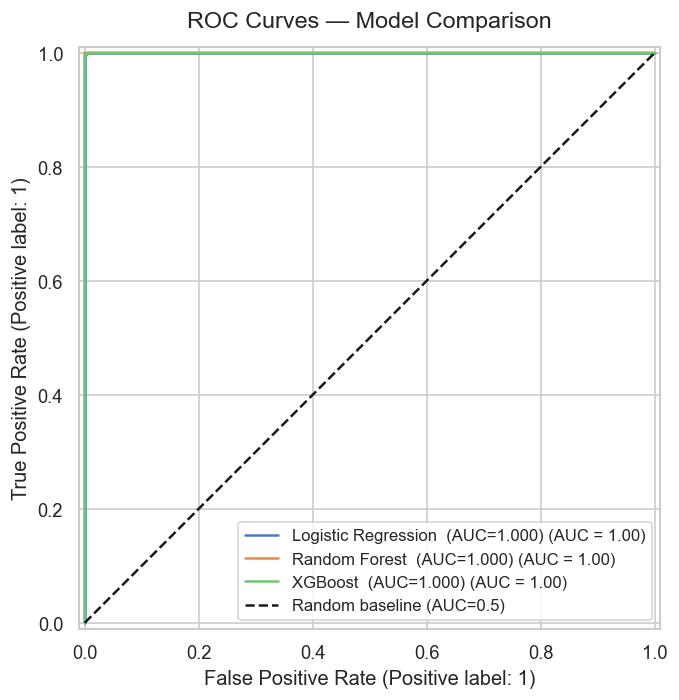

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, y_proba_lr,
    ax=ax, name=f'Logistic Regression  (AUC={lr_auc:.3f})')
RocCurveDisplay.from_predictions(
    y_test, y_proba_rf,
    ax=ax, name=f'Random Forest  (AUC={rf_auc:.3f})')
RocCurveDisplay.from_predictions(
    y_test, y_proba_xgb,
    ax=ax, name=f'XGBoost  (AUC={xgb_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC=0.5)')
ax.set_title('ROC Curves — Model Comparison', fontsize=14, pad=12)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/06_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print("Files saved:")
print("  data/processed/features_and_labels.csv")
print("  data/processed/model_comparison.csv")
print("  reports/figures/06_roc_curves.png")
print()
print("Model performance summary:")
print(results.to_string(index=False))
print()
print("Objects available for Day 3:")
print("  xgb         — trained XGBoost model")
print("  rf          — trained Random Forest model")
print("  X_test      — test feature set")
print("  y_test      — true churn labels")
print("  y_proba_xgb — XGBoost churn probabilities")
print("  rfm         — full feature table with all customers")
print()
print(f"Best ROC-AUC: {max(lr_auc, rf_auc, xgb_auc):.4f}")

Files saved:
  data/processed/features_and_labels.csv
  data/processed/model_comparison.csv
  reports/figures/06_roc_curves.png

Model performance summary:
              Model  ROC-AUC  F1 — Churned  Recall — Churned  Precision — Churned
Logistic Regression      1.0        0.9994            0.9989               0.9999
      Random Forest      1.0        1.0000            1.0000               1.0000
            XGBoost      1.0        0.9981            0.9968               0.9994

Objects available for Day 3:
  xgb         — trained XGBoost model
  rf          — trained Random Forest model
  X_test      — test feature set
  y_test      — true churn labels
  y_proba_xgb — XGBoost churn probabilities
  rfm         — full feature table with all customers

Best ROC-AUC: 1.0000
